In [1]:
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights, vgg16_bn, VGG16_BN_Weights
from torchsummary import summary
import numpy as np
# from cvat_sdk import make_client
# from cvat_sdk.pytorch import ProjectVisionDataset
from MLtools import ImageData
from torch.utils.data import DataLoader, random_split

from torchvision import transforms
from tqdm.notebook import tqdm

In [9]:
DETECTION_CLASSES = 6

class ResNet50(nn.Module):
    def __init__(self):
        super(ResNet50, self).__init__()
        

        self.conv = resnet50(weights=ResNet50_Weights.DEFAULT)
        for param in self.conv.parameters():
            param.requires_grad = False

        self.fc = nn.Sequential(
            nn.Linear(in_features = 1000, out_features = 1000, bias=True),
            nn.BatchNorm1d(1000, momentum = 0.5),
            nn.LeakyReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(in_features = 1000, out_features = 500, bias=True),
            nn.BatchNorm1d(500, momentum = 0.5),
            nn.LeakyReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(in_features = 500, out_features = 500, bias=True),
            nn.BatchNorm1d(500, momentum = 0.5),
            nn.LeakyReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(in_features = 500, out_features = DETECTION_CLASSES, bias=True),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        x = self.conv(x)
        # print(x.shape)
        x = self.fc(x)
        return x

In [10]:
class ClsTrainer(ResNet50):
    def __init__(self,
                lr,
                gamma,
                criterion):
        super(ClsTrainer, self).__init__()

        self.optim = torch.optim.Adam(super().parameters(), lr=lr)
        self.scheduler = torch.optim.lr_scheduler.ExponentialLR(self.optim, gamma=gamma)
        self.criterion = criterion
        self.epo_train_losses = []
        self.epo_val_losses = []

        self.train_losses = []
        self.val_losses = []

    def train_step(self, batch, target):
        self.train()
        self.optim.zero_grad()

        output = self.forward(batch)
        loss = self.criterion(output, target)

        loss.backward()
        self.optim.step()

        self.epo_train_losses.append(loss.item())

    def eval_step(self, batch, target):
        output = self.query(batch)
        loss = self.criterion(output, target)
        self.epo_val_losses.append(loss.item())

    def query(self, batch):
        self.eval()
        with torch.no_grad():
            output = self.forward(batch)

        return output

    def epoch_end(self):
        self.scheduler.step()

        self.train_losses.append(np.mean(self.epo_train_losses))
        self.val_losses.append(np.mean(self.epo_val_losses))

        self.epo_train_losses = []
        self.epo_val_losses = []

In [19]:
image_folder = "ext_data"
xml_path = "annotations.xml"
dataset = ImageData(image_folder, xml_path, True)

train_dataset, val_dataset = random_split(dataset, [9665, 100])
BS = 32

train_loader = DataLoader(train_dataset, 
                          batch_size=BS, 
                          shuffle=True,
                          pin_memory=True,
                          num_workers=16,
                          drop_last=True)

val_loader = DataLoader(val_dataset, 
                          batch_size=BS, 
                          shuffle=False,
                          pin_memory=True,
                          num_workers=16,
                          drop_last=True)


In [20]:
import ssl
ssl._create_default_https_context = ssl._create_stdlib_context

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

class_weights = torch.tensor([1.5, 1.0, 1.0, 1.0, 1.0, 1.0]).to(device)
classifier_criterion = torch.nn.BCELoss(weight = class_weights)

classifier = ClsTrainer(lr = 0.0005, gamma = 0.95, criterion = classifier_criterion).to(device)

# summary(classifier, (3,128,128))

In [21]:
# ~train loop
epoches = 5

for epo in tqdm(range(epoches)):
    for batch, target in train_loader:
        classifier.train_step(batch.to(device), target[:,0,:].to(device).float())

    for batch, target in val_loader:
        classifier.eval_step(batch.to(device), target[:,0,:].to(device).float())

    classifier.epoch_end()

  0%|          | 0/5 [00:00<?, ?it/s]

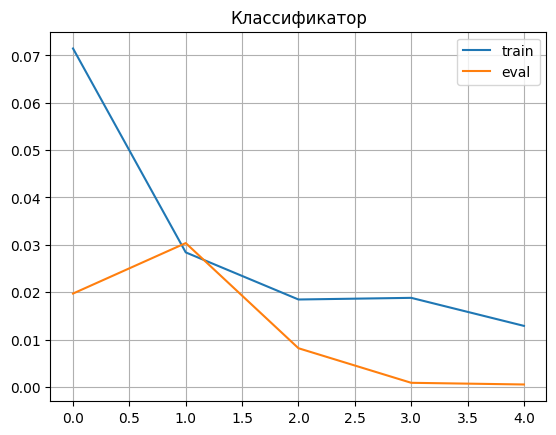

In [23]:
import matplotlib.pyplot as plt
plt.plot(classifier.train_losses, label='train')
plt.plot(classifier.val_losses, label='eval')
plt.title("Классификатор")
plt.legend()
plt.grid(True)

In [32]:
state_dict = classifier.state_dict()

del state_dict['criterion.weight']

torch.save(state_dict, "classifier.pth")

In [33]:
state_dict = torch.load('classifier.pth',weights_only=True)
model = ResNet50()



model.load_state_dict(state_dict)

<All keys matched successfully>